
# Empirical Study: Pseudonyms and Anonymity

## Course: 1DT114 Data Security and Privacy

This empirical study investigates the concepts of pseudonymisation, anonymisation, and k-anonymity discussed in the lecture materials.

Topics covered:
1. Pseudonymisation using hashing
2. Dictionary attacks
3. Quasi-identifiers
4. K-anonymity
5. Limitations of anonymisation


## 1. Import Libraries

In [1]:
# Install required packages
import subprocess
import sys
subprocess.check_call([sys.executable, "-m", "pip", "install", "pandas", "matplotlib"])


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 40.8 MB/s eta 0:00:00a 0:00:01



[notice] A new release of pip is available: 24.2 -> 26.1.1
[notice] To update, run: pip3 install --upgrade pip


0

In [2]:

import pandas as pd
import hashlib
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)



## 2. Create a Sample Dataset

The dataset contains:
- Identifiers
- Quasi-identifiers
- Sensitive attributes


In [4]:

data = {
    "Name": ["Alice", "Bob", "Charlie", "David", "Emma", "Fatima", "George", "Hannah"],
    "Email": [
        "alice.smith@gmail.com",
        "bob.jones@gmail.com",
        "charlie.khan@yahoo.com",
        "david.ali@gmail.com",
        "emma.johnson@outlook.com",
        "fatima.noor@gmail.com",
        "george.lee@yahoo.com",
        "hannah.wilson@gmail.com"
    ],
    "Age": [21, 22, 22, 35, 36, 35, 42, 43],
    "ZIP": ["75201", "75202", "75202", "10012", "10013", "10012", "60601", "60602"],
    "Gender": ["F", "M", "M", "M", "F", "F", "M", "F"],
    "Disease": ["Flu", "Cancer", "Diabetes", "Asthma", "Cancer", "Flu", "Diabetes", "Asthma"]
}

df = pd.DataFrame(data)
df


,Name,Email,Age,ZIP,Gender,Disease
0,Alice,alice.smith@gmail.com,21,75201,F,Flu
1,Bob,bob.jones@gmail.com,22,75202,M,Cancer
2,Charlie,charlie.khan@yahoo.com,22,75202,M,Diabetes
3,David,david.ali@gmail.com,35,10012,M,Asthma
4,Emma,emma.johnson@outlook.com,36,10013,F,Cancer
5,Fatima,fatima.noor@gmail.com,35,10012,F,Flu
6,George,george.lee@yahoo.com,42,60601,M,Diabetes
7,Hannah,hannah.wilson@gmail.com,43,60602,F,Asthma


## 3. Pseudonymisation Using Hashing

In [5]:

def hash_email(email):
    return hashlib.sha256(email.encode()).hexdigest()

df["Email_Hash"] = df["Email"].apply(hash_email)

pseudo_df = df.drop(columns=["Name", "Email"])
pseudo_df.head()


,Age,ZIP,Gender,Disease,Email_Hash
0,21,75201,F,Flu,d4e561b8ed6eadd056ac000dcb0ed6d5a1af7549110820...
1,22,75202,M,Cancer,01b69ffa1c20e3341fc98bee0f741a58bc2967d7c0a6a3...
2,22,75202,M,Diabetes,3227aeea4162df9925b401e1c6104ff7115a1ae156dcbf...
3,35,10012,M,Asthma,e122e99f837fa7101a3f6de8b7d4ffebe1165cd2f793a1...
4,36,10013,F,Cancer,164f3ba9b2b3dd3e80a6a5e76a6bf31be220278e045f1b...



### Observation

Email addresses are replaced by hashes.
This is pseudonymisation, not anonymisation.


## 4. Dictionary Attack Simulation

In [6]:

dictionary = [
    "alice.smith@gmail.com",
    "john.doe@gmail.com",
    "emma.johnson@outlook.com",
    "random.user@yahoo.com"
]

hashed_dictionary = {email: hash_email(email) for email in dictionary}

matches = []

for email, h in hashed_dictionary.items():
    if h in list(df["Email_Hash"]):
        matches.append((email, h))

matches_df = pd.DataFrame(matches, columns=["Recovered Email", "Matching Hash"])
matches_df


,Recovered Email,Matching Hash
0,alice.smith@gmail.com,d4e561b8ed6eadd056ac000dcb0ed6d5a1af7549110820...
1,emma.johnson@outlook.com,164f3ba9b2b3dd3e80a6a5e76a6bf31be220278e045f1b...



### Analysis

The attacker can recover emails using common patterns.
This demonstrates why hashing alone is insufficient for anonymity.


## 5. Quasi-Identifier Analysis

In [7]:

group_sizes = df.groupby(["Age", "ZIP", "Gender"]).size().reset_index(name="Count")
group_sizes


,Age,ZIP,Gender,Count
0,21,75201,F,1
1,22,75202,M,2
2,35,10012,F,1
3,35,10012,M,1
4,36,10013,F,1
5,42,60601,M,1
6,43,60602,F,1


In [ ]:

unique_records = group_sizes[group_sizes["Count"] == 1]
unique_records



### Observation

Some combinations uniquely identify individuals.
This creates linkability risks.


## 6. Applying K-Anonymity

In [8]:

anon_df = df.copy()

anon_df["ZIP"] = anon_df["ZIP"].str[:3] + "**"

anon_df["Age_Group"] = anon_df["Age"].apply(
    lambda x: "20-29" if x < 30 else ("30-39" if x < 40 else "40-49")
)

anon_df = anon_df.drop(columns=["Age", "Name", "Email", "Email_Hash"])

anon_df


,ZIP,Gender,Disease,Age_Group
0,752**,F,Flu,20-29
1,752**,M,Cancer,20-29
2,752**,M,Diabetes,20-29
3,100**,M,Asthma,30-39
4,100**,F,Cancer,30-39
5,100**,F,Flu,30-39
6,606**,M,Diabetes,40-49
7,606**,F,Asthma,40-49


In [9]:

k_groups = anon_df.groupby(["Age_Group", "ZIP", "Gender"]).size().reset_index(name="Count")
k_groups


,Age_Group,ZIP,Gender,Count
0,20-29,752**,F,1
1,20-29,752**,M,2
2,30-39,100**,F,2
3,30-39,100**,M,1
4,40-49,606**,F,1
5,40-49,606**,M,1



### Result

Generalisation increases the anonymity set and reduces unique identification.


## 7. Visualising Privacy Risk

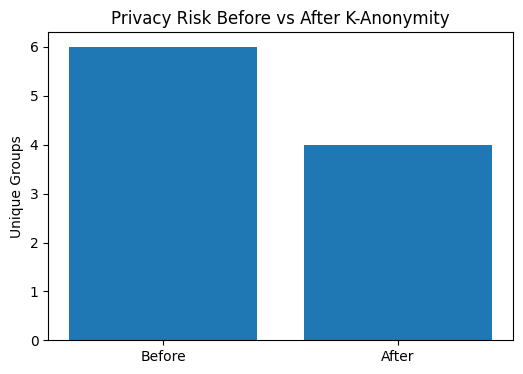

In [11]:

if 'unique_records' not in dir():
    group_sizes = df.groupby(["Age", "ZIP", "Gender"]).size().reset_index(name="Count")
    unique_records = group_sizes[group_sizes["Count"] == 1]

before_unique = len(unique_records)
after_unique = len(k_groups[k_groups["Count"] == 1])

labels = ["Before", "After"]
values = [before_unique, after_unique]

plt.figure(figsize=(6,4))
plt.bar(labels, values)
plt.ylabel("Unique Groups")
plt.title("Privacy Risk Before vs After K-Anonymity")
plt.show()



## 8. Conclusion

This study demonstrated:
- Pseudonymisation is not the same as anonymisation
- Hashes can be reversed through dictionary attacks
- Quasi-identifiers create linkage risks
- K-anonymity reduces re-identification risk
- Privacy-enhancing technologies have limitations
